## README
基于招新基本要求，学习借鉴《动手学深度学习pytorch版》（李沐）中的房价预测模型，我的环境配置再附录

### 数据清洗 & 特征工程

In [2]:
# 导入房价的文件
import os
data_file = os.path.join('..','chengdu_house_regression','data_file.csv')

# 拘灵遣将，展示神力
%matplotlib inline
from matplotlib_inline import backend_inline
from matplotlib import pyplot
import numpy as np
from datetime import datetime, timedelta
import pandas as pd
import re
import torch
from torch import nn 

# 开始操作文件
data = pd.read_csv(data_file)
print(data)

          序号 房屋所属市辖区 房屋地址（街道）      房屋户型        所在楼层  建筑面积（平方米） 户型结构  建筑类型  \
0          0      成华      驷马桥  3室2厅1厨1卫   高楼层 (共6层)     110.02   平层    板楼   
1          1      成华      猛追湾  4室1厅1厨2卫   高楼层 (共9层)     144.42   平层  板塔结合   
2          2      成华      驷马桥  7室4厅1厨4卫  低楼层 (共18层)     271.09   跃层  板塔结合   
3          3      成华      猛追湾  3室2厅1厨2卫   中楼层 (共7层)     113.41   平层    板楼   
4          4      成华      驷马桥  3室2厅1厨2卫  中楼层 (共18层)     123.70   平层    塔楼   
...      ...     ...      ...       ...         ...        ...  ...   ...   
14834  14743      青羊      外光华  2室1厅1厨1卫  高楼层 (共19层)      86.46   平层  板塔结合   
14835  14815      青羊     府南新区  2室1厅1厨1卫   高楼层 (共7层)      67.94   平层    板楼   
14836  14768      青羊     府南新区  2室1厅1厨1卫   高楼层 (共7层)      69.58   平层  板塔结合   
14837  14790      青羊      八宝街  1室2厅1厨1卫  低楼层 (共20层)      66.07   平层    板楼   
14838  14840      青羊      外金沙  2室1厅1厨1卫   高楼层 (共7层)      87.22   平层    板楼   

      房屋朝向  建筑结构 装修情况 配备电梯        挂牌时间   交易权属  房屋用途    Price  
0      南 北  

In [3]:
# 查看一下毛特征和样本数量级
print(data.shape)
# 标签选取
all_lables = data.iloc[:, -1]

(14839, 16)


In [4]:
# 初步选取我要的特征值（题干要求的）
features1 = data.iloc[:, 3:6]
features2 = data.iloc[:, 8:13]
all_features = pd.concat((features1, features2), axis=1)
all_features


,房屋户型,所在楼层,建筑面积（平方米）,房屋朝向,建筑结构,装修情况,配备电梯,挂牌时间
0,3室2厅1厨1卫,高楼层 (共6层),110.02,南 北,砖混结构,毛坯,无,44248
1,4室1厅1厨2卫,高楼层 (共9层),144.42,南,框架结构,精装,有,44521
2,7室4厅1厨4卫,低楼层 (共18层),271.09,南,钢混结构,简装,有,44533
3,3室2厅1厨2卫,中楼层 (共7层),113.41,南,混合结构,简装,无,44532
4,3室2厅1厨2卫,中楼层 (共18层),123.70,南 北,钢混结构,毛坯,有,44544
...,...,...,...,...,...,...,...,...
14834,2室1厅1厨1卫,高楼层 (共19层),86.46,南 北,钢混结构,精装,有,44504
14835,2室1厅1厨1卫,高楼层 (共7层),67.94,南,砖混结构,简装,无,2020/10/13
14836,2室1厅1厨1卫,高楼层 (共7层),69.58,南,砖混结构,其他,无,2021/11/2
14837,1室2厅1厨1卫,低楼层 (共20层),66.07,西北,框架结构,其他,有,44313


In [5]:
# 先统一日期格式
def date_to_excel(date_str):
    if isinstance(date_str, str):
        if '/' in date_str:
            excel_base = datetime(1899, 12, 30)
            date_obj = pd.to_datetime(date_str)
            return (date_obj - excel_base).days
        if date_str.isdigit():
            return int(date_str)
    else:
        return date_str
# 太阴了，居然有纯数字字符串，我没有实现预览全部数据，洗这个数据我洗了好久，我不行了...
all_features['挂牌时间'] = all_features['挂牌时间'].apply(lambda x: date_to_excel(x))

# 正则化户型
def extract_layout_numbers(layout_str):
    if not layout_str or pd.isna(layout_str):
        return [0, 0, 0, 0]
    pattern = r'(\d+)室(\d+)厅(\d+)厨(\d+)卫'
    match = re.match(pattern, str(layout_str))
    if match:
        return [int(match.group(1)),  
                int(match.group(2)),  
                int(match.group(3)),  
                int(match.group(4))]
    else:
        return [0, 0, 0, 0]   
all_features['房屋户型'] = all_features['房屋户型'].apply(lambda x: extract_layout_numbers(x))
# 正则特征提取
all_features['室'] = all_features['房屋户型'].apply(lambda x: x[0])
all_features['厅'] = all_features['房屋户型'].apply(lambda x: x[1])
all_features['厨'] = all_features['房屋户型'].apply(lambda x: x[2])
all_features['卫'] = all_features['房屋户型'].apply(lambda x: x[3])
all_features = all_features.drop('房屋户型',axis=1)

In [6]:
# 获取纯数字特征
numeric_features = all_features.dtypes[all_features.dtypes != 'object'].index
print(numeric_features)
all_features.shape

Index(['建筑面积（平方米）', '挂牌时间', '室', '厅', '厨', '卫'], dtype='object')


(14839, 11)

In [7]:
# 标准化和独热编码
all_features[numeric_features] = all_features[numeric_features].apply(lambda x: (x - x.mean()) / (x.std()))
all_features[numeric_features] = all_features[numeric_features].fillna(0)
all_features = pd.get_dummies(all_features, columns=['所在楼层','房屋朝向','建筑结构','装修情况','配备电梯'],dummy_na=True)
print(all_features.shape)
all_features
# 其实这样进行独热编码有点浪费，对于特征‘所在楼层’，我本来是想把他们数值化的，后面放弃了

(14839, 261)


,建筑面积（平方米）,挂牌时间,室,厅,厨,卫,所在楼层_中楼层 (共10层),所在楼层_中楼层 (共11层),所在楼层_中楼层 (共12层),所在楼层_中楼层 (共13层),...,建筑结构_钢结构,建筑结构_nan,装修情况_其他,装修情况_毛坯,装修情况_简装,装修情况_精装,装修情况_nan,配备电梯_无,配备电梯_有,配备电梯_nan
0,0.207724,-0.356352,0.328305,0.857810,-0.032003,-0.789333,False,False,False,False,...,False,False,False,True,False,False,False,True,False,False
1,1.058731,0.709031,1.443625,-0.946704,-0.032003,0.866202,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False
2,4.192369,0.755861,4.789586,4.466837,-0.032003,4.177273,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
3,0.291588,0.751959,0.328305,0.857810,-0.032003,0.866202,False,False,False,False,...,False,False,False,False,True,False,False,True,False,False
4,0.546148,0.798789,0.328305,0.857810,-0.032003,0.866202,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14834,-0.375117,0.642689,-0.787015,-0.946704,-0.032003,-0.789333,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False
14835,-0.833276,-0.867580,-0.787015,-0.946704,-0.032003,-0.789333,False,False,False,False,...,False,False,False,False,True,False,False,True,False,False
14836,-0.792705,0.634884,-0.787015,-0.946704,-0.032003,-0.789333,False,False,False,False,...,False,False,True,False,False,False,False,True,False,False
14837,-0.879537,-0.102690,-1.902335,0.857810,-0.032003,-0.789333,False,False,False,False,...,False,False,True,False,False,False,False,False,True,False


In [8]:
# 转Numpy格式, 再取前0.8作为训练集
# 后续我想可学习一下K折交叉验证，改进一下代码
n_train = int(data.shape[0] * 0.8)
train_features = torch.tensor(all_features[:n_train].values, dtype=torch.float32)
test_features = torch.tensor(all_features[n_train:-1].values, dtype=torch.float32)
train_lables = torch.tensor(
    all_lables[:n_train].values.reshape(-1,1), dtype=torch.float32
)
test_lables = torch.tensor(
    all_lables[n_train:-1].values.reshape(-1,1), dtype=torch.float32
)
pre_features = torch.tensor(all_features[-1:].values, dtype=torch.float32)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "d:\anacanda\envs\ML\lib\runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "d:\anacanda\envs\ML\lib\runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "d:\anacanda\envs\ML\lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "d:\anacanda\envs\ML\lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "d:\anacanda\envs\ML\lib\site-packages\ipykernel\kernelapp

In [9]:
from torch.utils import data
# 随机批量iterator
def load_array(data_arrays, batch_size, is_train=True):
    dataset = data.TensorDataset(*data_arrays)
    return data.DataLoader(dataset, batch_size, shuffle=is_train)

### 训练

In [10]:
loss = nn.MSELoss()
in_features = train_features.shape[1]

# 还是一个一个封装好再写入模型比较漂亮
def get_net():
    net = nn.Sequential(nn.Linear(in_features, 1))
    return net

# 均方根误差
def rmse(net, features, lables):
    clipped_preds = torch.clamp(net(features), 1 , float('inf'))
    rsmes = torch.sqrt(loss(clipped_preds, lables)) 
    return rsmes.item()

In [11]:
def train(net, train_features, train_lables, test_features, test_lables,
          num_epochs, learning_rate, weight_decay, batch_size):
    train_ls, test_ls = [], []
    train_iter = load_array((train_features, train_lables), batch_size)
    # Amad优化器
    optimizer = torch.optim.Adam(net.parameters(),
                                 lr = learning_rate,
                                 weight_decay = weight_decay)
    for epoch in range(num_epochs):
        for X, y in train_iter:
            optimizer.zero_grad()
            l = loss(net(X), y)
            l.backward()
            optimizer.step()
        train_ls.append(rmse(net ,train_features, train_lables))
        if test_lables is not None:
            test_ls.append(rmse(net, test_features, test_lables))
    return train_ls, test_ls

In [12]:
# 可视化操作,模仿李沐深度学习的可视化封装
def use_svg_display():
    backend_inline.set_matplotlib_formats('svg')

def set_figsize(figsize=(3.5,2.5)):
    use_svg_display()
    pyplot.rcParams['figure.figsize'] = figsize

def set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend):
    axes.set_xlabel(xlabel)
    axes.set_ylabel(ylabel)
    axes.set_xscale(xscale)
    axes.set_yscale(yscale)
    axes.set_xlim(xlim)
    axes.set_ylim(ylim)
    if legend:
        axes.legend(legend)
    axes.grid()

def plot(X, Y = None, xlabel=None, ylabel=None, legend=None, xlim=None, ylim=None,
         xscale='linear', yscale='linear',fmts=('-','m--','g-.','r:'), figsize=(3.5,2.5),
         axes=None):
    if legend is None:
        legend = []
    set_figsize(figsize)
    axes = axes if axes else pyplot.gca()
    def has_one_axis(X):
        return (hasattr(X,"ndim") and X.ndim == 1 or isinstance(X, list) and not hasattr(X[0],"__len__"))
    if has_one_axis(X):
        X =[X]
    if Y is None:
        X, Y = [[]] *len(X), X
    elif has_one_axis(Y):
        X = X*len(Y)
    axes.cla()
    for x, y, fmt in zip(X,Y,fmts):
        if len(x):
            axes.plot(x,y,fmt)
        else:
            axes.plot(y,fmt)
    set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend)

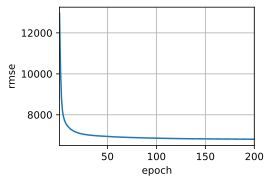

In [13]:
net = get_net()
num_epochs = 200
lr = 5
weight_decay = 0
batch_size = 64

train_ls, test_ls = train(net, train_features, train_lables, test_features, test_lables, 
                          num_epochs, lr, weight_decay, batch_size)
plot(np.arange(1, num_epochs + 1), [train_ls], xlabel='epoch', ylabel='rmse', 
         xlim=[1, num_epochs])

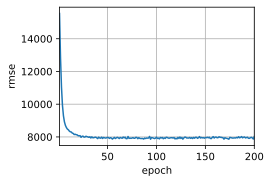

In [14]:
plot(np.arange(1, num_epochs + 1), [test_ls], xlabel='epoch', ylabel='rmse', 
         xlim=[1, num_epochs])

In [15]:
torch.save(net.state_dict(), 'house_price_model.pth')

net = get_net()
net.load_state_dict(torch.load('house_price_model.pth'))
net.eval()
with torch.no_grad():
        prediction = net(pre_features)
prediction.item()


12212.876953125